### Circuit RLC - Reconstruction de la réponse temporelle avec la réponse harmonique

L’objectif de ce TP est d’étudier la réponse temporelle du circuit RLC pour différentes valeurs de coefficient
d’amortissement. Le schéma du circuit est illustré ci-dessous.


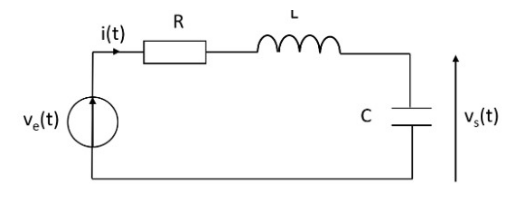

In [1]:
from PIL import Image
import matplotlib.pyplot as plt

# Chemin vers l'image sur ton PC
chemin_image = r"C:\Users\loica\OneDrive\Desktop\image\img1.jpg"

# Ouvrir l'image
image = Image.open(chemin_image)

# Afficher l'image
plt.imshow(image)
plt.axis("off")
plt.show()

1. Ecrire l'équation différentielle régissant la dynamique de sortie de ce système.


La loi des mailles donne :

$$
u_e = u_R + u_L + u_C
$$

Avec

$$
u_R = R\,i
\qquad ; \qquad
u_L = L\,\frac{di}{dt}
\qquad \text{et} \qquad
i = C\,\frac{du_C}{dt}
$$

Il vient donc rapidement :

$$
LC\,\frac{d^2u_C}{dt^2} + RC\,\frac{du_C}{dt} + u_C = u_e
$$

2.Donner la fonction de transfert

$$
\text{Il vient immédiatement } \left[ LC \cdot p^2 + RC \cdot p + 1 \right] \, u_C(p) = u_e(p)
$$

$$
\frac{u_C(p)}{u_e(p)} = \frac{1}{LC \cdot p^2 + RC \cdot p + 1}
$$

$$
\left\{
\begin{aligned}
\omega_n &= \frac{1}{\sqrt{LC}} \\
\xi &= \frac{\omega_n}{2}\,RC
\end{aligned}
\right.
$$

$$
\left\{
\begin{aligned}
\text{Gain statique} &= 1 \\
\omega_n &= \frac{1}{\sqrt{LC}} \\
\xi &= \frac{R}{2}\sqrt{\frac{C}{L}}
\end{aligned}
\right.
$$

In [2]:
import control as ctrl

# Paramètres
R = 1e3
L = 0.1
C = 1e-9

# Numérateur et dénominateur
num = [1]
den = [L*C, R*C, 1]

# Fonction de transfert
H = ctrl.tf(num, den)

print(H)

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

             1
  -----------------------
  1e-10 s^2 + 1e-06 s + 1


### avec python pour tracer la reponse temporel u_C(t) on as pas besoin de faire la transformer de laplace inverse comme dans matlab on peut directement tracer la reponse temporel qui est la reponse indicielle lorque l'entree est un echelon . pour cela on as utiliser 3 methode en python 

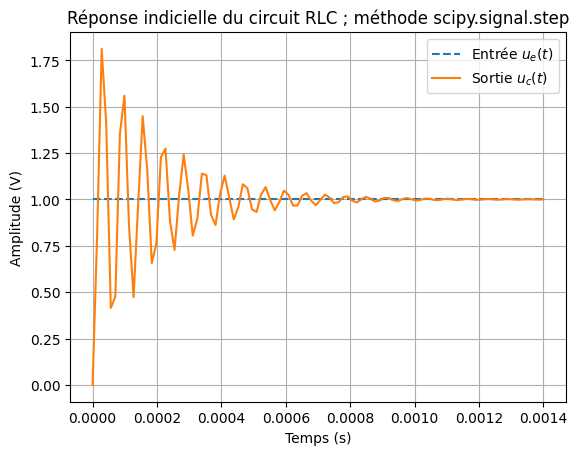

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Paramètres
R = 1e3
L = 0.1
C = 1e-9

# Système de transfert
system = signal.TransferFunction([1], [L*C, R*C, 1])

# Réponse indicielle
t, uc = signal.step(system)

# Entrée : échelon unitaire
ue = np.ones_like(t)

# Affichage
plt.plot(t, ue, label="Entrée $u_e(t)$", linestyle="--")
plt.plot(t, uc, label="Sortie $u_c(t)$")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude (V)")
plt.title("Réponse indicielle du circuit RLC ; méthode scipy.signal.step")
plt.legend()
plt.grid(True)
plt.show()

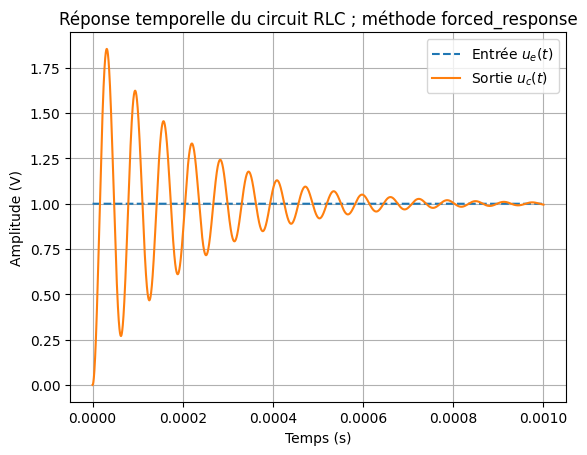

In [12]:
import control as ctrl
import numpy as np
import matplotlib.pyplot as plt

# Paramètres
R = 1e3
L = 0.1
C = 1e-9

# Fonction de transfert
H = ctrl.tf([1], [L*C, R*C, 1])

# Axe temporel
# lorsqu'on change le pas, la courbe est plus ou moins espacée
t = np.linspace(0, 0.001, 5000)

# Entrée : échelon unitaire
e = np.ones_like(t)

# Réponse forcée
t_out, uc = ctrl.forced_response(H, T=t, U=e)

# Affichage
plt.plot(t, e, label="Entrée $u_e(t)$", linestyle="--")
plt.plot(t_out, uc, label="Sortie $u_c(t)$")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude (V)")
plt.title("Réponse temporelle du circuit RLC ; méthode forced_response")
plt.legend()
plt.grid(True)
plt.show()

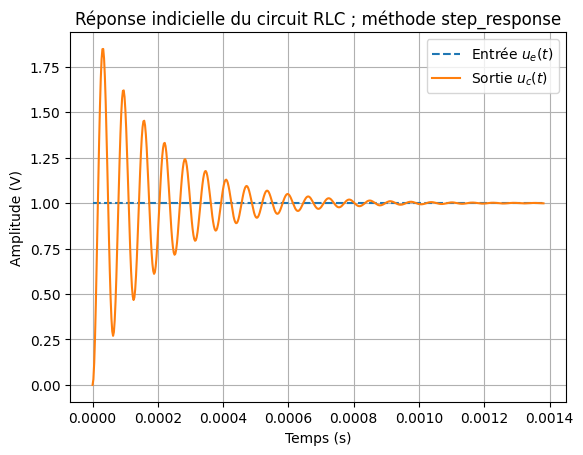

In [9]:
import control as ctrl
import matplotlib.pyplot as plt
import numpy as np

# Paramètres
R = 1e3
L = 0.1
C = 1e-9

# Fonction de transfert H(p)
H = ctrl.tf([1], [L*C, R*C, 1])

# Réponse indicielle
t, uc = ctrl.step_response(H)

# Signal d'entrée : échelon unitaire
ue = np.ones_like(t)

# Affichage
plt.plot(t, ue, label="Entrée $u_e(t)$", linestyle="--")
plt.plot(t, uc, label="Sortie $u_c(t)$")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude (V)")
plt.title("Réponse indicielle du circuit RLC ; méthode step_response")
plt.legend()
plt.grid(True)
plt.show()

### dans la suite du TP nous allons utiliser signal périodique carré parce qu’il permet de montrer expérimentalement que :la reponse temporelle d’un systeme lineaire peut etre reconstruite a partir de sa reponse harmonique . alors l'entre du systeme est remplacer par un signal carre periode on parle de reponse harmonique ce qui etait le but de notre tp 


## Décomposition en série de Fourier et reconstruction de la solution

Fonction de transfert isochrone :

$$
H(\omega)=\frac{1}{1+jRC\omega-LC\omega^2}
$$

Décomposition du signal d’entrée :

$$
V_e(t)=a_0+\sum_{n=1}^{\infty} a_n\cos(n\omega t)+b_n\sin(n\omega t)
$$

Reconstruction du signal de sortie :

$$
V_s(t)=a_0H(0)+\sum_{n=1}^{\infty}
a_n|H(n\omega)|\cos\left(n\omega t+\arg\{H(n\omega)\}\right)
+b_n|H(n\omega)|\sin\left(n\omega t+\arg\{H(n\omega)\}\right)
$$

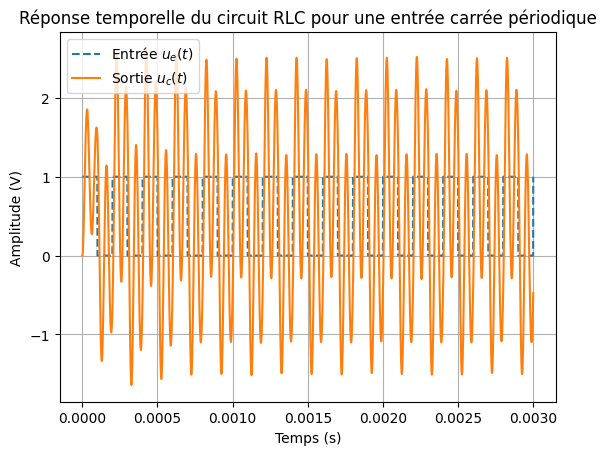

In [17]:
import control as ctrl
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Paramètres du circuit
R = 1e3
L = 0.1
C = 1e-9

# Fonction de transfert H(p)
H = ctrl.tf([1], [L*C, R*C, 1])

# Paramètres du signal carré
F = 5e3              # fréquence = 5 kHz
T = 1 / F            # période
tmax = 15* T        # durée totale = 15 périodes

# Axe temporel
t = np.linspace(0, tmax, 5000)

# Signal carré périodique entre 0 et 1 V
# signal.square donne un signal entre -1 et +1
# donc on transforme pour obtenir 0 à 1
ue = 0.5 * (signal.square(2 * np.pi * F * t) + 1)

# Réponse temporelle du système
t_out, uc = ctrl.forced_response(H, T=t, U=ue)

# Tracé
plt.plot(t, ue, '--', label="Entrée $u_e(t)$")
plt.plot(t_out, uc, label="Sortie $u_c(t)$")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude (V)")
plt.title("Réponse temporelle du circuit RLC pour une entrée carrée périodique")
plt.legend()
plt.grid(True)
plt.show()

# Lorque je modifie la valeur de tmax =T on as 

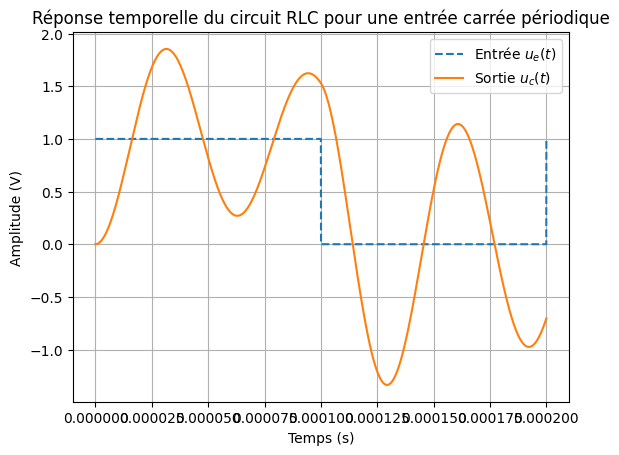

In [18]:
import control as ctrl
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Paramètres du circuit
R = 1e3
L = 0.1
C = 1e-9

# Fonction de transfert H(p)
H = ctrl.tf([1], [L*C, R*C, 1])

# Paramètres du signal carré
F = 5e3              # fréquence = 5 kHz
T = 1 / F            # période
tmax = T        # durée totale = 15 périodes

# Axe temporel
t = np.linspace(0, tmax, 5000)

# Signal carré périodique entre 0 et 1 V
# signal.square donne un signal entre -1 et +1
# donc on transforme pour obtenir 0 à 1
ue = 0.5 * (signal.square(2 * np.pi * F * t) + 1)

# Réponse temporelle du système
t_out, uc = ctrl.forced_response(H, T=t, U=ue)

# Tracé
plt.plot(t, ue, '--', label="Entrée $u_e(t)$")
plt.plot(t_out, uc, label="Sortie $u_c(t)$")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude (V)")
plt.title("Réponse temporelle du circuit RLC pour une entrée carrée périodique")
plt.legend()
plt.grid(True)
plt.show()